# Klasifikasi Penyakit Ginjal Kronis (Chronic Kidney Disease) Menggunakan Machine Learning

### Anggota Kelompok
- Muhammad Reyenno Rakhazhillan Sashiqinthara – 103012300326
- Muhammad Andhika Mefiandi – 103012300016
- I Made Dwi Wiryawan Raditya – 103012300142

## 1. Pendahuluan

Penyakit Ginjal Kronis atau Chronic Kidney Disease (CKD) adalah kondisi ketika fungsi ginjal menurun secara bertahap dalam jangka waktu panjang. CKD merupakan salah satu masalah kesehatan global yang cukup serius karena dapat menimbulkan berbagai komplikasi berat, bahkan berujung pada kematian apabila tidak ditangani secara tepat. Berbagai faktor risiko turut berkontribusi terhadap munculnya CKD, termasuk tekanan darah tinggi, diabetes, anemia, serta kelainan pada darah dan urin.

Dengan kemajuan teknologi, pendekatan machine learning kini banyak dimanfaatkan untuk membantu memprediksi penyakit berdasarkan data medis pasien. Melalui analisis data laboratorium dan kondisi klinis, algoritma machine learning mampu mengenali pola yang sulit diidentifikasi secara manual oleh tenaga medis.

Dalam proyek ini, dilakukan proses klasifikasi penyakit ginjal kronis menggunakan tiga algoritma machine learning, yaitu Logistic Regression, Decision Tree, dan K-Nearest Neighbor (KNN). Penelitian ini bertujuan untuk membandingkan performa ketiga metode tersebut dalam memprediksi apakah seorang pasien terindikasi menderita penyakit ginjal kronis atau tidak.



## 2. Rumusan Masalah
1. Bagaimana performa algoritma Logistic Regression, Decision Tree, dan KNN dalam mengklasifikasikan penyakit ginjal kronis?
2. Algoritma manakah yang menghasilkan kinerja terbaik berdasarkan nilai evaluasi yang digunakan?


## 3. Tujuan Penelitian
...

## 4. Deskripsi Dataset

Dataset yang digunakan dalam penelitian ini adalah Chronic Kidney Disease (CKD) Dataset yang diperoleh dari platform Kaggle. Dataset ini memuat data medis pasien yang mencakup berbagai parameter kesehatan, seperti usia, tekanan darah, kadar gula darah, hasil pemeriksaan urin, serta indikator klinis lainnya. Secara keseluruhan, dataset terdiri dari sekitar 400 data pasien dengan 25 atribut fitur dan 1 label target.

Label target yang digunakan adalah variabel class, yang merepresentasikan kondisi pasien, yaitu:
- 1 : menunjukkan pasien menderita penyakit ginjal kronis (CKD),
- 0 : menunjukkan pasien dalam kondisi normal.

Dataset ini memiliki karakteristik berupa kombinasi data numerik dan kategorikal, serta mengandung sejumlah missing value. Oleh karena itu, diperlukan tahapan data preprocessing terlebih dahulu agar data siap digunakan dalam proses pemodelan machine learning.

## 5. Preprocessing Data

In [91]:
# Import Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


In [2]:
# Baca Data
df = pd.read_csv("kidney_disease.csv")
# Lihat 5 baris pertama
print("Preview Data:")
display(df.head())

Preview Data:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
# Bentuk dataset
print("Shape:", df.shape)

Shape: (400, 26)


In [4]:
# Menghilangakn kolom id
df.drop('id', axis = 1, inplace = True)

In [5]:
# Ganti nama Kolom agar mudah di baca
df.rename(columns={
    'age':'age',
    'bp':'blood_pressure',
    'sg':'specific_gravity',
    'al':'albumin',
    'su':'sugar',
    'rbc':'red_blood_cells',
    'pc':'pus_cell',
    'pcc':'pus_cell_clumps',
    'ba':'bacteria',
    'bgr':'blood_glucose_random',
    'bu':'blood_urea',
    'sc':'serum_creatinine',
    'sod':'sodium',
    'pot':'potassium',
    'hemo':'hemoglobin',
    'pcv':'packed_cell_volume',
    'wc':'white_blood_cell_count',
    'rc':'red_blood_cell_count',
    'htn':'hypertension',
    'dm':'diabetes_mellitus',
    'cad':'coronary_artery_disease',
    'appet':'appetite',
    'pe':'pedal_edema',
    'ane':'anemia',
    'classification':'class'
}, inplace=True)

In [6]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [7]:
# Statistik dasar
df.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,hemoglobin
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [8]:
# Informasi tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  hemoglobin               3

#### Karena ada tipe data yang tidak sesuai, dimana tabel 'packed_cell_volume', 'white_blood_cell_count' dan 'red_blood_cell_count' itu seharusnya angka, maka harus kita ubah dulu untuk tipe datanya ke numerik

In [9]:
# Mengubah kolom ke numerik
df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors='coerce')
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'], errors='coerce')
df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'], errors='coerce')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  hemoglobin               3

#### Mengekstraksi Data

In [11]:
# Mengekstraksi kolom kategorikal dan numerik
kategori = [col for col in df.columns if df[col].dtype == 'object']
numerik = [col for col in df.columns if df[col].dtype != 'object']

In [12]:
# Melihat nilai unik dalam kolom kategorikal
for col in kategori:
    print(f"{col} has {df[col].unique()} values\n")

red_blood_cells has [nan 'normal' 'abnormal'] values

pus_cell has ['normal' 'abnormal' nan] values

pus_cell_clumps has ['notpresent' 'present' nan] values

bacteria has ['notpresent' 'present' nan] values

hypertension has ['yes' 'no' nan] values

diabetes_mellitus has ['yes' 'no' ' yes' '\tno' '\tyes' nan] values

coronary_artery_disease has ['no' 'yes' '\tno' nan] values

appetite has ['good' 'poor' nan] values

pedal_edema has ['no' 'yes' nan] values

anemia has ['no' 'yes' nan] values

class has ['ckd' 'ckd\t' 'notckd'] values



#### Terdapat beberapa ambiguitas pada kolom-kolom tersebut, kita harus menghilangkannya.

In [13]:
# Membenarkan tulisan pada tabel
df['diabetes_mellitus'] = df['diabetes_mellitus'].replace({'\tno':'no','\tyes':'yes', ' yes':'yes'})

df['coronary_artery_disease'] = df['coronary_artery_disease'].replace({'\tno': 'no'})

df['class'] = df['class'].replace({'ckd\t': 'ckd', 'notckd': 'not ckd'})

In [14]:
# Mengubah 'ckd' menjadi 1 dan 'not ckd' menjadi 0
df['class'] = df['class'].map({'ckd': 1, 'not ckd': 0})

In [15]:
for col in kategori:
    print(f"{col} has {df[col].unique()} values\n")

red_blood_cells has [nan 'normal' 'abnormal'] values

pus_cell has ['normal' 'abnormal' nan] values

pus_cell_clumps has ['notpresent' 'present' nan] values

bacteria has ['notpresent' 'present' nan] values

hypertension has ['yes' 'no' nan] values

diabetes_mellitus has ['yes' 'no' nan] values

coronary_artery_disease has ['no' 'yes' nan] values

appetite has ['good' 'poor' nan] values

pedal_edema has ['no' 'yes' nan] values

anemia has ['no' 'yes' nan] values

class has [1 0] values



#### Memperbaiki nilai yang kosong

In [16]:
# Cek data yang kosong
df.isna().sum().sort_values(ascending = False)

red_blood_cells            152
red_blood_cell_count       131
white_blood_cell_count     106
potassium                   88
sodium                      87
packed_cell_volume          71
pus_cell                    65
hemoglobin                  52
sugar                       49
specific_gravity            47
albumin                     46
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
blood_pressure              12
age                          9
pus_cell_clumps              4
bacteria                     4
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
pedal_edema                  1
anemia                       1
class                        0
dtype: int64

In [17]:
df[numerik].isnull().sum()

age                         9
blood_pressure             12
specific_gravity           47
albumin                    46
sugar                      49
blood_glucose_random       44
blood_urea                 19
serum_creatinine           17
sodium                     87
potassium                  88
hemoglobin                 52
packed_cell_volume         71
white_blood_cell_count    106
red_blood_cell_count      131
dtype: int64

In [18]:
df[kategori].isnull().sum()

red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
pedal_edema                  1
anemia                       1
class                        0
dtype: int64

#### Mengisi nilai kosong atau null pada data numerik

In [19]:
# Mengisi data yang kosong menggunakan median
for col in numerik:
    df[col] = df[col].fillna(df[col].median())

In [20]:
df[numerik].isnull().sum()

age                       0
blood_pressure            0
specific_gravity          0
albumin                   0
sugar                     0
blood_glucose_random      0
blood_urea                0
serum_creatinine          0
sodium                    0
potassium                 0
hemoglobin                0
packed_cell_volume        0
white_blood_cell_count    0
red_blood_cell_count      0
dtype: int64

#### Mengisi nilai kosong atau null pada data kategori

In [21]:
# Mengisi data yang kosong dengan modus
for col in kategori:
    df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
df[kategori].isnull().sum()

red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
pedal_edema                0
anemia                     0
class                      0
dtype: int64

### Matriks Kolerasi

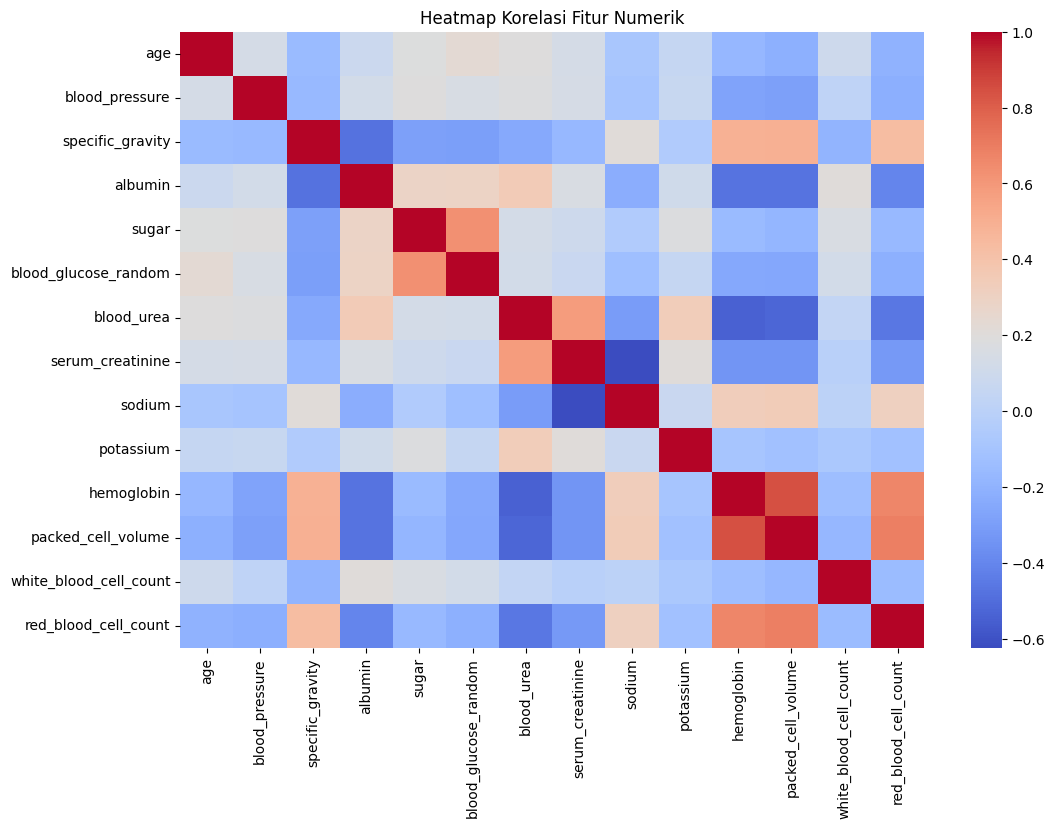

In [50]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numerik].corr(), cmap='coolwarm')
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()


### Data Visualization

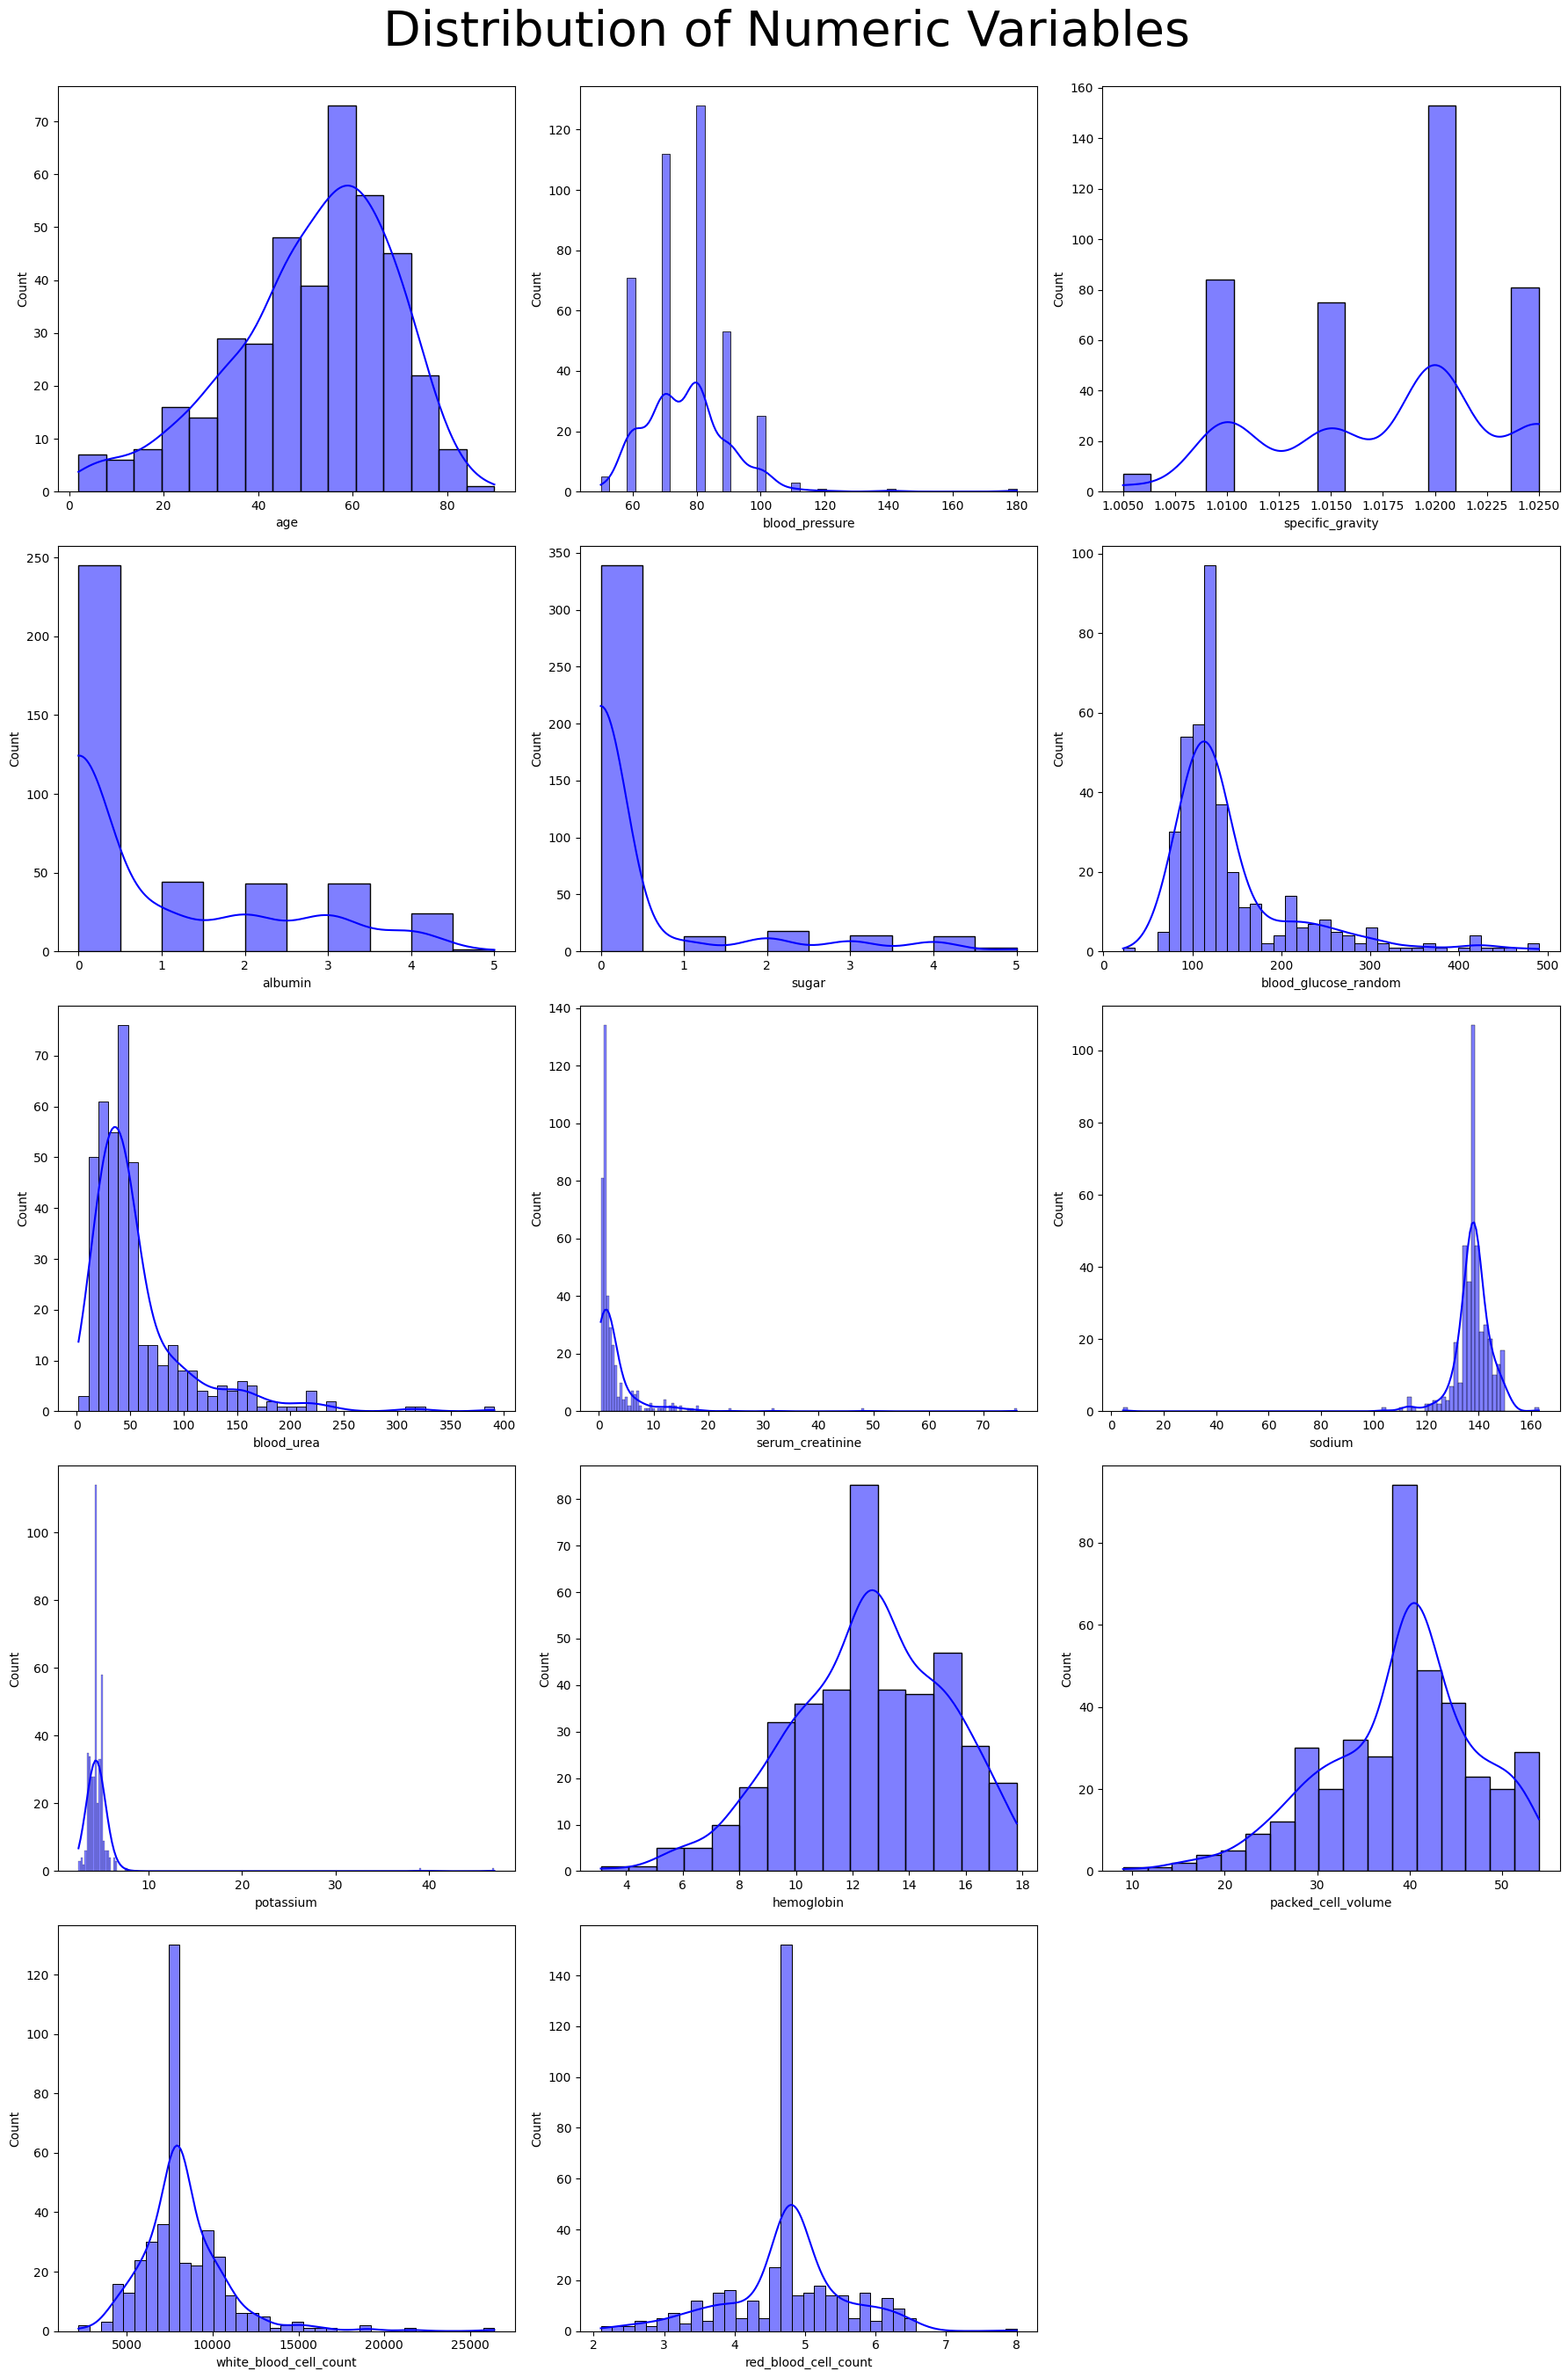

In [53]:
plt.figure(figsize=(18, 27))
plotnumber = 1

for col in numerik:
    if plotnumber <= len(numerik):
        ax = plt.subplot(5, 3, plotnumber)
        sns.histplot(x=df[col], kde=True, color='blue')
        plt.xlabel(col)
        
    plotnumber += 1

plt.suptitle('Distribution of Numeric Variables', fontsize=40, y=1)
plt.tight_layout()
plt.show()


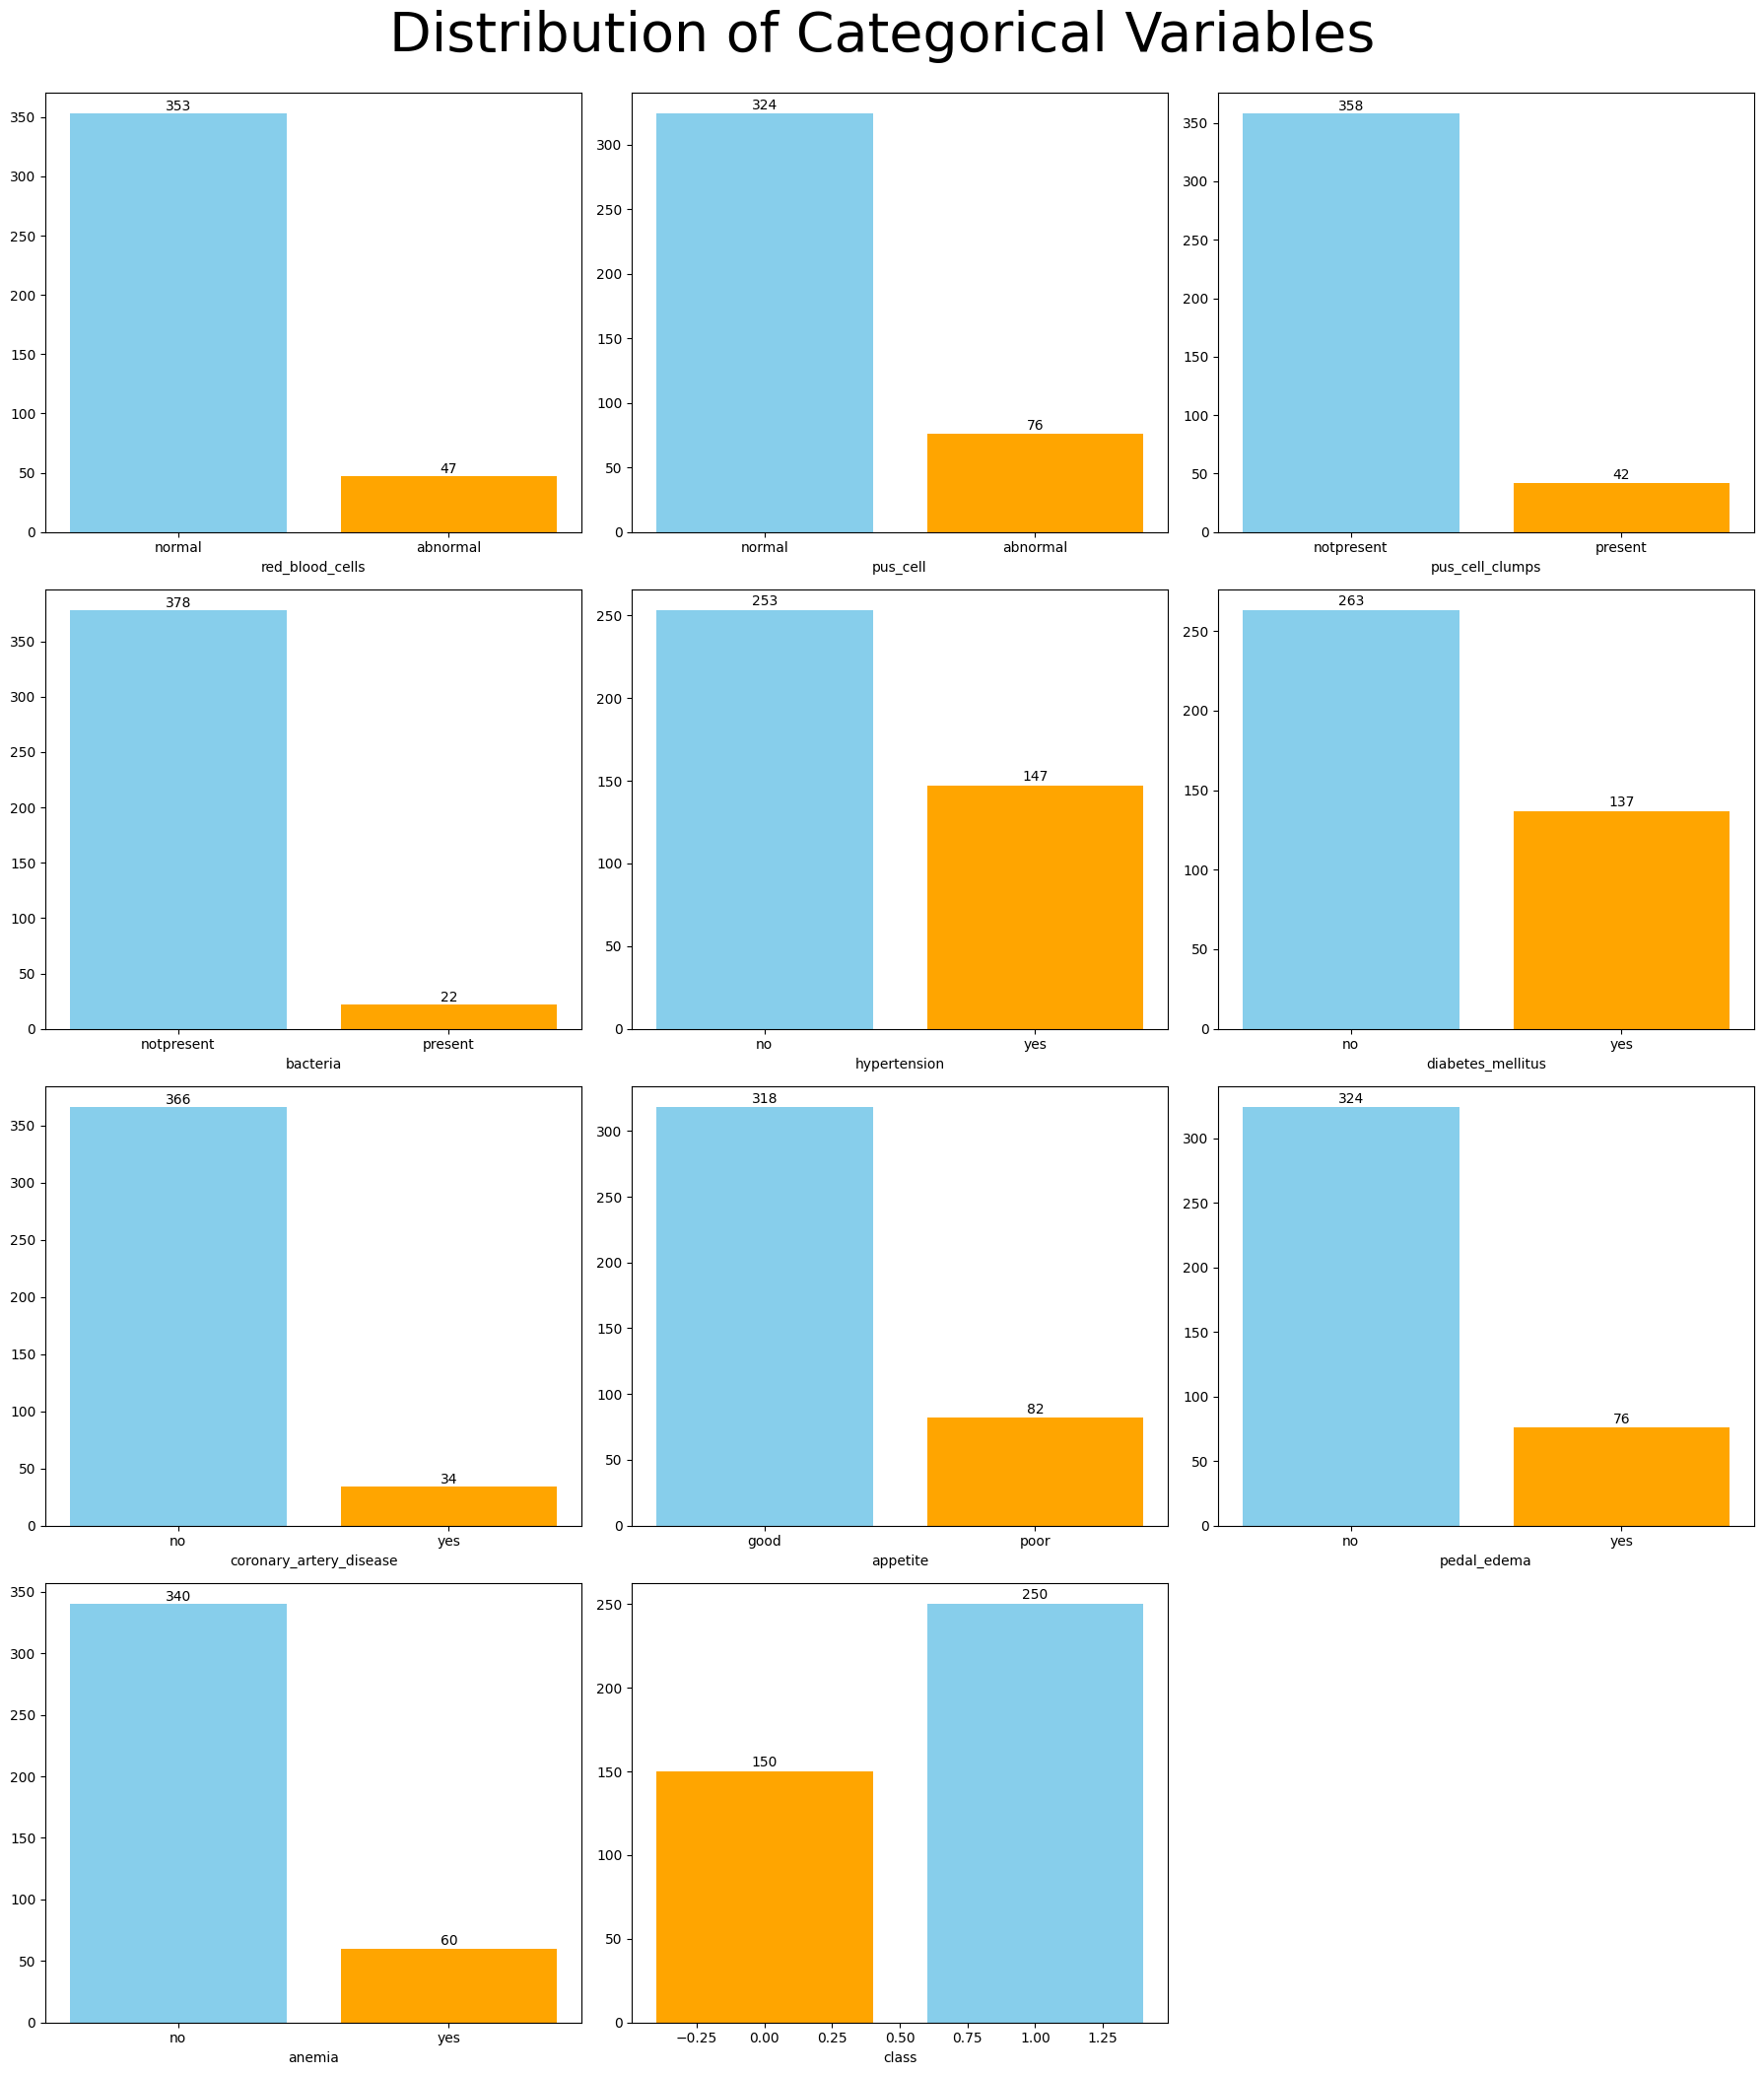

In [54]:
plt.figure(figsize=(18, 21))
plotnumber = 1

colors = ['skyblue', 'orange', 'lightgreen', 'salmon', 'lightcoral', 'cyan', 'pink']

for col in kategori:
    if plotnumber <= len(kategori):
        ax = plt.subplot(4, 3, plotnumber)
        # sns.countplot(x=df[col], palette = 'pastel')
        counts = df[col].value_counts()
        ax.bar(counts.index, counts.values, color=colors[:len(counts)])
        
        # Add labels to each bar in the plot
        for p in ax.patches:
            ax.text(p.get_x()+p.get_width()/2, p.get_height()+3, f'{p.get_height()}', ha="center")
        
        plt.xlabel(col)
        
    plotnumber += 1

plt.suptitle('Distribution of Categorical Variables', fontsize=40, y=1)
plt.tight_layout()
plt.show()

#### Memeriksa apakah data memiliki outlier

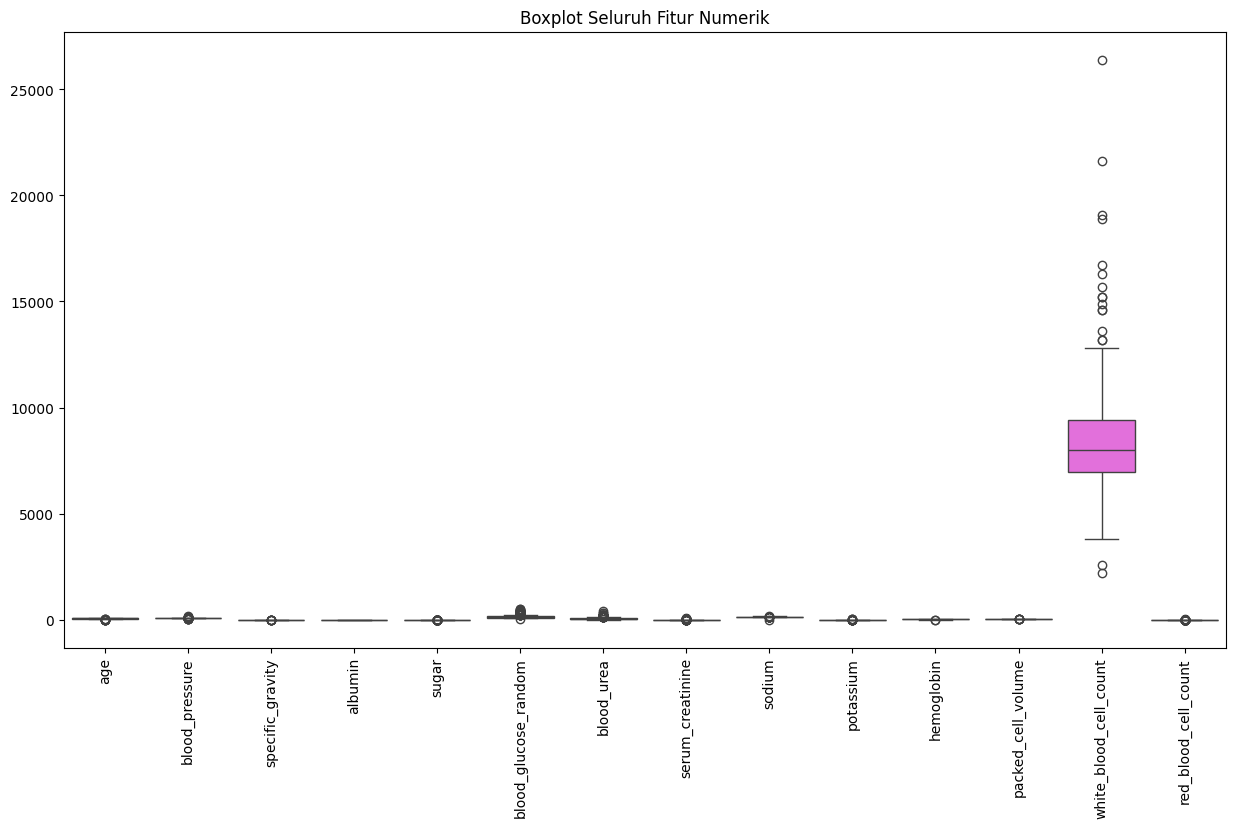

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))
sns.boxplot(data=df[numerik])
plt.xticks(rotation=90)
plt.title("Boxplot Seluruh Fitur Numerik")
plt.show()

#### Karena data terlalu besar skalanya jadi dibagi menjadi per kelompok agar semua box terlihat

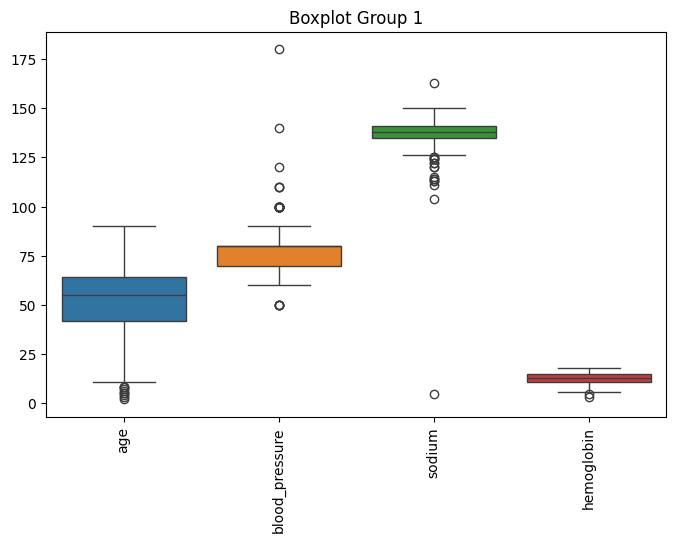

In [24]:
group1 = ['age', 'blood_pressure', 'sodium', 'hemoglobin']

plt.figure(figsize=(8,5))
sns.boxplot(data=df[group1])
plt.xticks(rotation=90)
plt.title("Boxplot Group 1")
plt.show()

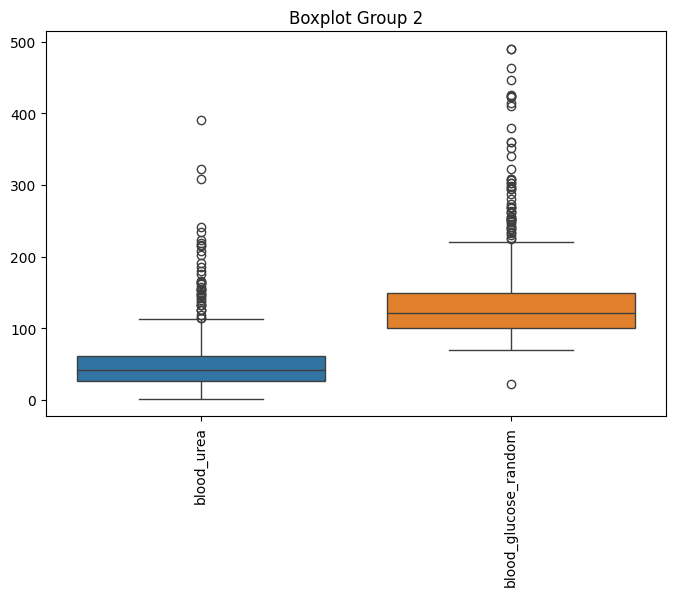

In [25]:
group2 = ['blood_urea', 'blood_glucose_random']

plt.figure(figsize=(8,5))
sns.boxplot(data=df[group2])
plt.xticks(rotation=90)
plt.title("Boxplot Group 2")
plt.show()

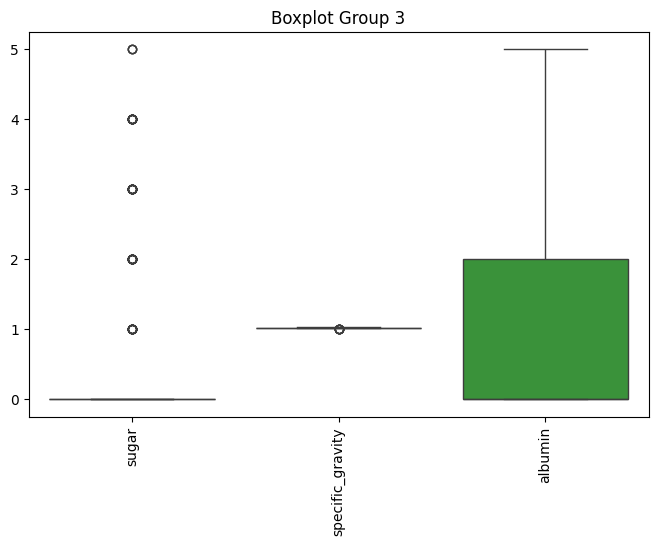

In [26]:
group3 = ['sugar','specific_gravity', 'albumin']

plt.figure(figsize=(8,5))
sns.boxplot(data=df[group3])
plt.xticks(rotation=90)
plt.title("Boxplot Group 3")
plt.show()


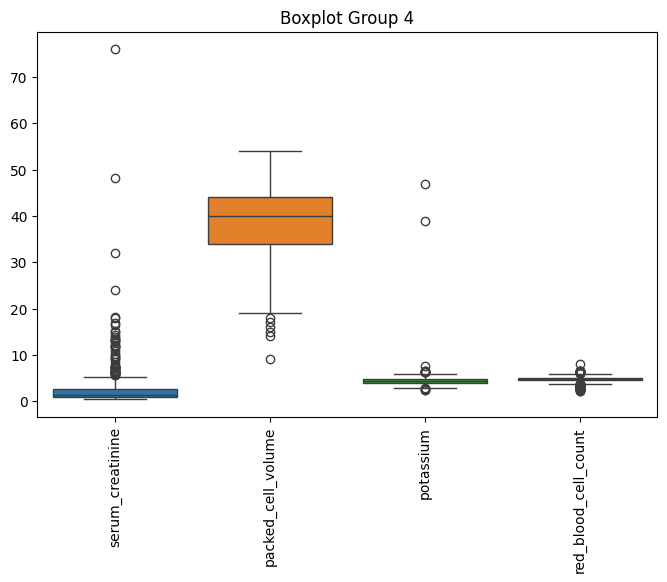

In [27]:
group4 = ['serum_creatinine', 'packed_cell_volume', 'potassium',  'red_blood_cell_count']

plt.figure(figsize=(8,5))
sns.boxplot(data=df[group4])
plt.xticks(rotation=90)
plt.title("Boxplot Group 4")
plt.show()


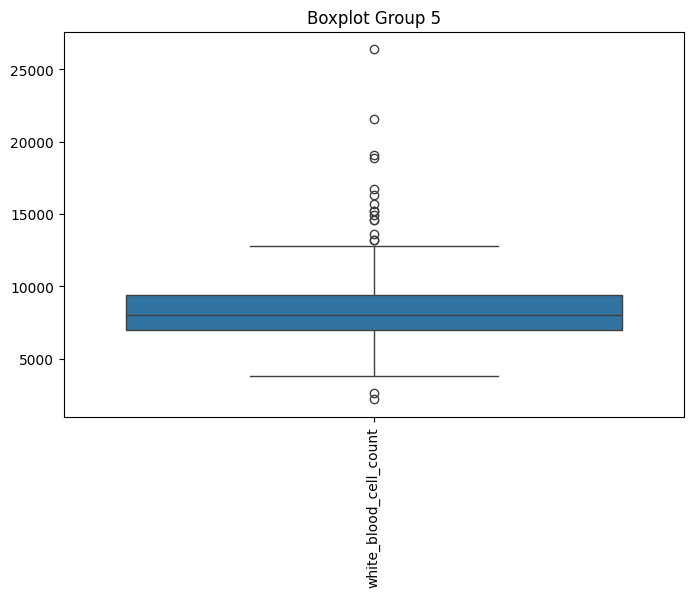

In [28]:
group5 = ['white_blood_cell_count']

plt.figure(figsize=(8,5))
sns.boxplot(data=df[group5])
plt.xticks(rotation=90)
plt.title("Boxplot Group 5")
plt.show()

In [29]:
df.shape

(400, 25)

#### Penghapusan outlier

In [30]:
# Sebagian Outlier di hapus
dfA = df.copy()

outlier_cols_A = [
    'blood_pressure',
    'blood_glucose_random',
    'blood_urea',
    'serum_creatinine',
    'white_blood_cell_count'
]

for col in outlier_cols_A:
    Q1 = dfA[col].quantile(0.25)
    Q3 = dfA[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    dfA = dfA[(dfA[col] >= lower) & (dfA[col] <= upper)]


In [64]:
df0 = df.copy()

In [31]:
# Semua outlier di hapus
dfB = df.copy()

for col in numerik:
    Q1 = dfB[col].quantile(0.25)
    Q3 = dfB[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    dfB = dfB[(dfB[col] >= lower) & (dfB[col] <= upper)]


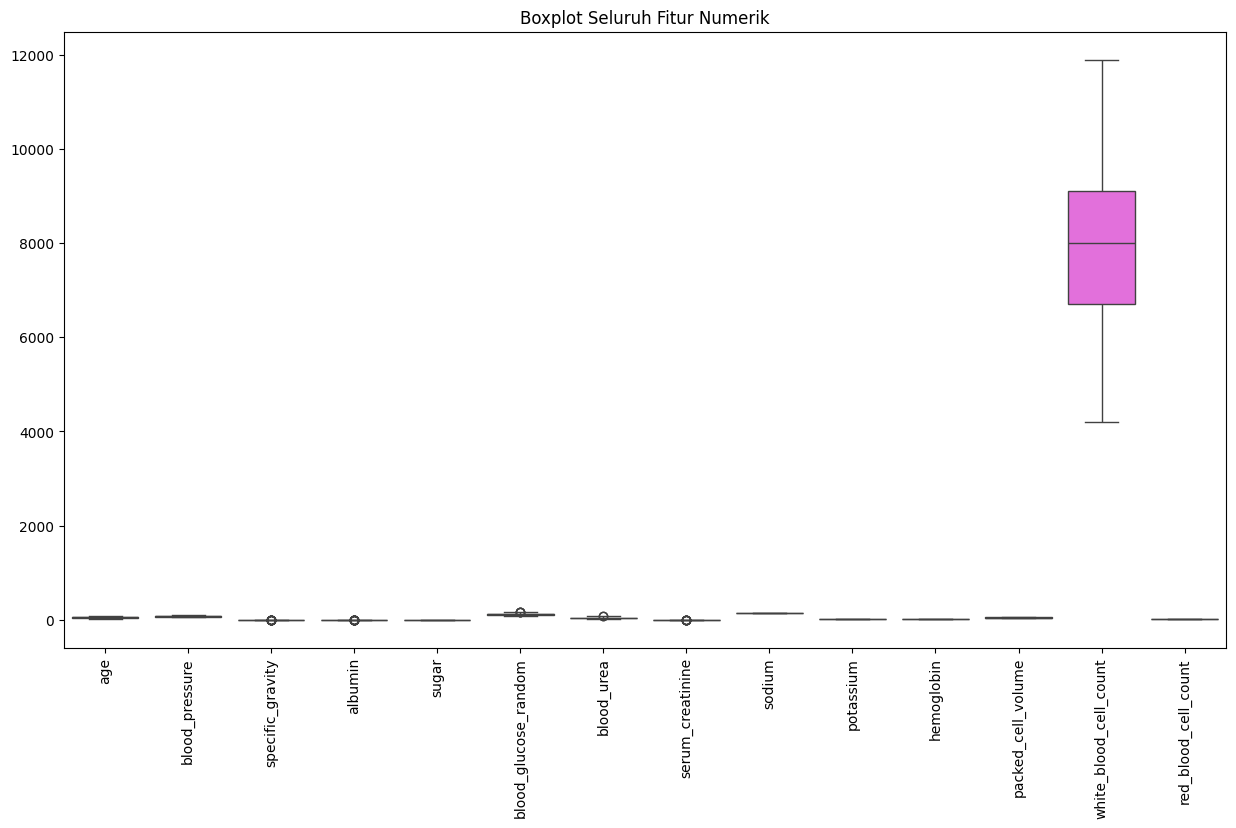

In [32]:
plt.figure(figsize=(15,8))
sns.boxplot(data=dfB[numerik])
plt.xticks(rotation=90)
plt.title("Boxplot Seluruh Fitur Numerik")
plt.show()

In [33]:
dfB.shape

(197, 25)

In [34]:
dfA.shape

(233, 25)

In [35]:
dfB['class'].value_counts()

class
0    150
1     47
Name: count, dtype: int64

In [36]:
dfA['class'].value_counts()

class
0    150
1     83
Name: count, dtype: int64

#### Encoding Data Kategorikal

In [37]:

cat_cols = ['red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
            'hypertension', 'diabetes_mellitus', 'coronary_artery_disease',
            'appetite', 'pedal_edema', 'anemia']

for c in cat_cols:
    print(c, ":", dfA[c].unique())

red_blood_cells : ['normal' 'abnormal']
pus_cell : ['normal' 'abnormal']
pus_cell_clumps : ['notpresent' 'present']
bacteria : ['notpresent' 'present']
hypertension : ['yes' 'no']
diabetes_mellitus : ['yes' 'no']
coronary_artery_disease : ['no' 'yes']
appetite : ['good' 'poor']
pedal_edema : ['no' 'yes']
anemia : ['no' 'yes']


In [56]:
# buat salinan untuk modeling
df_model = dfA.copy()

df_model = df_model.replace({
    'red_blood_cells': { 'normal': 0, 'abnormal': 1 },
    'pus_cell':        { 'normal': 0, 'abnormal': 1 },
    'pus_cell_clumps': { 'notpresent': 0, 'present': 1 },
    'bacteria':        { 'notpresent': 0, 'present': 1 },
    'hypertension':   { 'no': 0, 'yes': 1 },
    'diabetes_mellitus': { 'no': 0, 'yes': 1 },
    'coronary_artery_disease': { 'no': 0, 'yes': 1 },
    'appetite':       { 'good': 0, 'poor': 1 },
    'pedal_edema':    { 'no': 0, 'yes': 1 },
    'anemia':         { 'no': 0, 'yes': 1 }
})

# Pastikan hasil tetap numerik
df_model = df_model.infer_objects(copy=False)


In [58]:
for c in cat_cols + ['class']:
    print(c, ":", df_model[c].unique())


red_blood_cells : [0 1]
pus_cell : [0 1]
pus_cell_clumps : [0 1]
bacteria : [0 1]
hypertension : [1 0]
diabetes_mellitus : [1 0]
coronary_artery_disease : [0 1]
appetite : [0 1]
pedal_edema : [0 1]
anemia : [0 1]
class : [1 0]


## Data Training and Testing

In [65]:
def cek_object(df, name="df"):
    obj_cols = df.select_dtypes(include='object').columns
    print(f"[{name}] Kolom object:", list(obj_cols))
    for c in obj_cols:
        print(c, "->", df[c].unique()[:10])
    print()

cek_object(df0, "df0")
cek_object(dfA, "dfA")
cek_object(dfB, "dfB")


[df0] Kolom object: ['red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria', 'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'pedal_edema', 'anemia']
red_blood_cells -> ['normal' 'abnormal']
pus_cell -> ['normal' 'abnormal']
pus_cell_clumps -> ['notpresent' 'present']
bacteria -> ['notpresent' 'present']
hypertension -> ['yes' 'no']
diabetes_mellitus -> ['yes' 'no']
coronary_artery_disease -> ['no' 'yes']
appetite -> ['good' 'poor']
pedal_edema -> ['no' 'yes']
anemia -> ['no' 'yes']

[dfA] Kolom object: ['red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria', 'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'pedal_edema', 'anemia']
red_blood_cells -> ['normal' 'abnormal']
pus_cell -> ['normal' 'abnormal']
pus_cell_clumps -> ['notpresent' 'present']
bacteria -> ['notpresent' 'present']
hypertension -> ['yes' 'no']
diabetes_mellitus -> ['yes' 'no']
coronary_artery_disease -> ['no' 'yes']
appetite -> ['good' 'poor']
pedal_

In [71]:
encoder = {
    'red_blood_cells': {'normal': 0, 'abnormal': 1},
    'pus_cell': {'normal': 0, 'abnormal': 1},
    'pus_cell_clumps': {'notpresent': 0, 'present': 1},
    'bacteria': {'notpresent': 0, 'present': 1},
    'hypertension': {'no': 0, 'yes': 1},
    'diabetes_mellitus': {'no': 0, 'yes': 1},
    'coronary_artery_disease': {'no': 0, 'yes': 1},
    'appetite': {'good': 0, 'poor': 1},
    'pedal_edema': {'no': 0, 'yes': 1},
    'anemia': {'no': 0, 'yes': 1},
}

def apply_encoding(df):
    df = df.copy()

    # rapikan spasi/tab biar mapping kena
    for c in df.select_dtypes(include='object').columns:
        df[c] = df[c].astype(str).str.strip().str.replace('\t', '', regex=False)

    # encoding kategorikal
    df = df.replace(encoder)

    # pastikan beberapa kolom angka yang sering kebaca object jadi numeric
    maybe_numeric = ['packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count']
    for c in maybe_numeric:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    # (opsional) buang id kalau ada
    df.drop(columns=['id'], inplace=True, errors='ignore')

    return df

df0_enc = apply_encoding(df0)
dfA_enc = apply_encoding(dfA)
dfB_enc = apply_encoding(dfB)


In [72]:
def prepare_train_test(df, label_col='class'):
    X = df.drop(columns=[label_col])
    y = df[label_col].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test

In [73]:
# tanpa hapus outlier
Xtr0, Xte0, ytr0, yte0 = prepare_train_test(df0_enc)

# hapus sebagian outlier
XtrA, XteA, ytrA, yteA = prepare_train_test(dfA_enc)

# hapus semua outlier
XtrB, XteB, ytrB, yteB = prepare_train_test(dfB_enc)


In [75]:
print("Train:", Xtr0.shape, ytr0.shape)
print("Test :", Xte0.shape, yte0.shape)

print("Train:", XtrA.shape, ytrA.shape)
print("Test :", XteA.shape, yteA.shape)

print("Train:", XtrB.shape, ytrB.shape)
print("Test :", XteB.shape, yteB.shape)

Train: (320, 24) (320,)
Test : (80, 24) (80,)
Train: (186, 24) (186,)
Test : (47, 24) (47,)
Train: (157, 24) (157,)
Test : (40, 24) (40,)


## Logistic Regression

In [77]:
def train_logistic_regression(X_train, X_test, y_train, y_test, name):
    print(f"\n===== LOGISTIC REGRESSION ({name}) =====")

    model = LogisticRegression(max_iter=3000, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"Akurasi: {acc:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    return acc


In [78]:
# Tanpa hapus outlier
acc_0 = train_logistic_regression(Xtr0, Xte0, ytr0, yte0, "Tanpa Penghapusan Outlier")

# Hapus sebagian outlier
acc_A = train_logistic_regression(XtrA, XteA, ytrA, yteA, "Outlier Dihapus Sebagian")

# Hapus semua outlier
acc_B = train_logistic_regression(XtrB, XteB, ytrB, yteB, "Outlier Dihapus Semua")



===== LOGISTIC REGRESSION (Tanpa Penghapusan Outlier) =====
Akurasi: 0.9875

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80


===== LOGISTIC REGRESSION (Outlier Dihapus Sebagian) =====
Akurasi: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        17

    accuracy                           1.00        47
   macro avg       1.00      1.00      1.00        47
weighted avg       1.00      1.00      1.00        47


===== LOGISTIC REGRESSION (Outlier Dihapus Semua) =====
Akurasi: 0.9500

Classification Report:
              precision    recall  f1-score   su

In [80]:
hasil_lr = pd.DataFrame({
    "Perlakuan Data": [
        "Tanpa Penghapusan Outlier",
        "Outlier Dihapus Sebagian",
        "Outlier Dihapus Semua"
    ],
    "Akurasi": [acc_0, acc_A, acc_B]
})

hasil_lr

,Perlakuan Data,Akurasi
0,Tanpa Penghapusan Outlier,0.9875
1,Outlier Dihapus Sebagian,1.0000
2,Outlier Dihapus Semua,0.9500


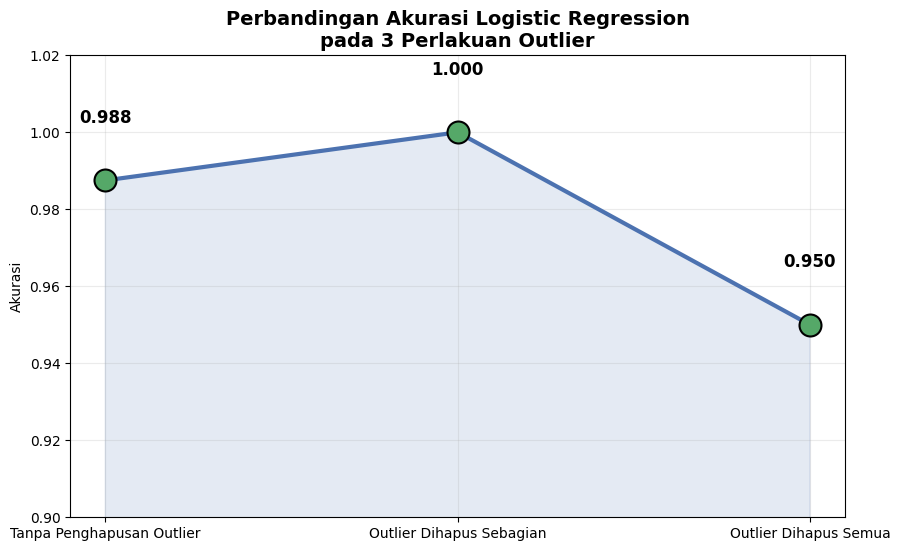

In [82]:
models = [
    "Tanpa Penghapusan Outlier",
    "Outlier Dihapus Sebagian",
    "Outlier Dihapus Semua"
]

acc_values = np.array([acc_0, acc_A, acc_B])

plt.figure(figsize=(10, 6))

line_color = "#4C72B0"
point_color = "#55A868"

# garis
plt.plot(models, acc_values, color=line_color, linewidth=3)

# titik
plt.scatter(
    models,
    acc_values,
    color=point_color,
    s=250,
    edgecolors="black",
    linewidth=1.5,
    zorder=5
)

# area bayangan
plt.fill_between(models, acc_values, color=line_color, alpha=0.15)

# label nilai akurasi
for i, val in enumerate(acc_values):
    plt.text(
        i,
        val + 0.015,
        f"{val:.3f}",
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title(
    "Perbandingan Akurasi Logistic Regression\npada 3 Perlakuan Outlier",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel("Akurasi")
plt.ylim(min(acc_values) - 0.05, 1.02)
plt.grid(alpha=0.25)

plt.show()


## Decision Tree

In [89]:
def train_dt(Xtr, Xte, ytr, yte, name,
             criterion="gini", max_depth=None):
    print(f"\n===== DECISION TREE ({name}) =====")

    model = DecisionTreeClassifier(
        random_state=42,
        criterion=criterion,
        max_depth=max_depth
    )

    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)

    acc = accuracy_score(yte, y_pred)
    print(f"Akurasi: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(yte, y_pred))

    return acc


In [92]:
acc_dt_0 = train_dt(Xtr0, Xte0, ytr0, yte0, "Tanpa Penghapusan Outlier")
acc_dt_A = train_dt(XtrA, XteA, ytrA, yteA, "Outlier Dihapus Sebagian")
acc_dt_B = train_dt(XtrB, XteB, ytrB, yteB, "Outlier Dihapus Semua")



===== DECISION TREE (Tanpa Penghapusan Outlier) =====
Akurasi: 0.9875

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80


===== DECISION TREE (Outlier Dihapus Sebagian) =====
Akurasi: 0.9787

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.94      0.97        17

    accuracy                           0.98        47
   macro avg       0.98      0.97      0.98        47
weighted avg       0.98      0.98      0.98        47


===== DECISION TREE (Outlier Dihapus Semua) =====
Akurasi: 0.9000

Classification Report:
              precision    recall  f1-score   support

           

In [93]:
hasil_dt = pd.DataFrame({
    "Perlakuan Data": [
        "Tanpa Penghapusan Outlier",
        "Outlier Dihapus Sebagian",
        "Outlier Dihapus Semua"
    ],
    "Akurasi": [acc_dt_0, acc_dt_A, acc_dt_B]
})

hasil_dt


,Perlakuan Data,Akurasi
0,Tanpa Penghapusan Outlier,0.987500
1,Outlier Dihapus Sebagian,0.978723
2,Outlier Dihapus Semua,0.900000


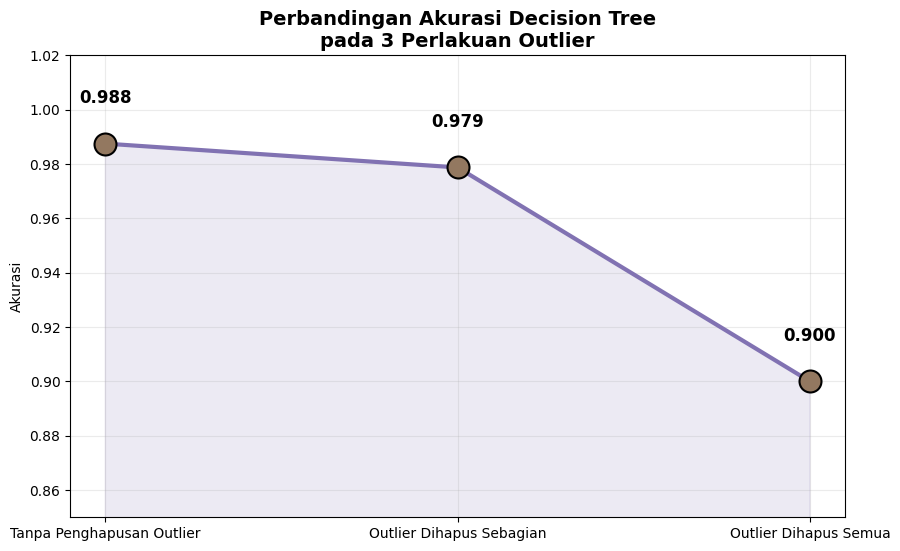

In [94]:
models = [
    "Tanpa Penghapusan Outlier",
    "Outlier Dihapus Sebagian",
    "Outlier Dihapus Semua"
]

acc_values = np.array([acc_dt_0, acc_dt_A, acc_dt_B])

plt.figure(figsize=(10, 6))

line_color = "#8172B2"
point_color = "#937860"

plt.plot(models, acc_values, color=line_color, linewidth=3)
plt.scatter(models, acc_values, color=point_color, s=250,
            edgecolors="black", linewidth=1.5, zorder=5)
plt.fill_between(models, acc_values, color=line_color, alpha=0.15)

for i, val in enumerate(acc_values):
    plt.text(i, val + 0.015, f"{val:.3f}",
             ha='center', fontsize=12, fontweight='bold')

plt.title(
    "Perbandingan Akurasi Decision Tree\npada 3 Perlakuan Outlier",
    fontsize=14,
    fontweight='bold'
)
plt.ylabel("Akurasi")
plt.ylim(min(acc_values) - 0.05, 1.02)
plt.grid(alpha=0.25)
plt.show()


## K-Nearest Neighbors (KNN)

In [83]:
def train_knn(X_train, X_test, y_train, y_test, name, k=5):
    print(f"\n===== KNN ({name}) | k={k} =====")

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"Akurasi: {acc:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    return acc


In [84]:
# Tanpa hapus outlier
acc_knn_0 = train_knn(Xtr0, Xte0, ytr0, yte0, "Tanpa Penghapusan Outlier", k=5)

# Hapus sebagian outlier
acc_knn_A = train_knn(XtrA, XteA, ytrA, yteA, "Outlier Dihapus Sebagian", k=5)

# Hapus semua outlier
acc_knn_B = train_knn(XtrB, XteB, ytrB, yteB, "Outlier Dihapus Semua", k=5)



===== KNN (Tanpa Penghapusan Outlier) | k=5 =====
Akurasi: 0.9750

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        30
           1       1.00      0.96      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80


===== KNN (Outlier Dihapus Sebagian) | k=5 =====
Akurasi: 0.9362

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        30
           1       1.00      0.82      0.90        17

    accuracy                           0.94        47
   macro avg       0.95      0.91      0.93        47
weighted avg       0.94      0.94      0.93        47


===== KNN (Outlier Dihapus Semua) | k=5 =====
Akurasi: 0.9250

Classification Report:
              precision    recall  f1-score   support

           0       0.91

In [85]:
hasil_knn = pd.DataFrame({
    "Perlakuan Data": [
        "Tanpa Penghapusan Outlier",
        "Outlier Dihapus Sebagian",
        "Outlier Dihapus Semua"
    ],
    "Akurasi": [acc_knn_0, acc_knn_A, acc_knn_B]
})

hasil_knn


,Perlakuan Data,Akurasi
0,Tanpa Penghapusan Outlier,0.97500
1,Outlier Dihapus Sebagian,0.93617
2,Outlier Dihapus Semua,0.92500


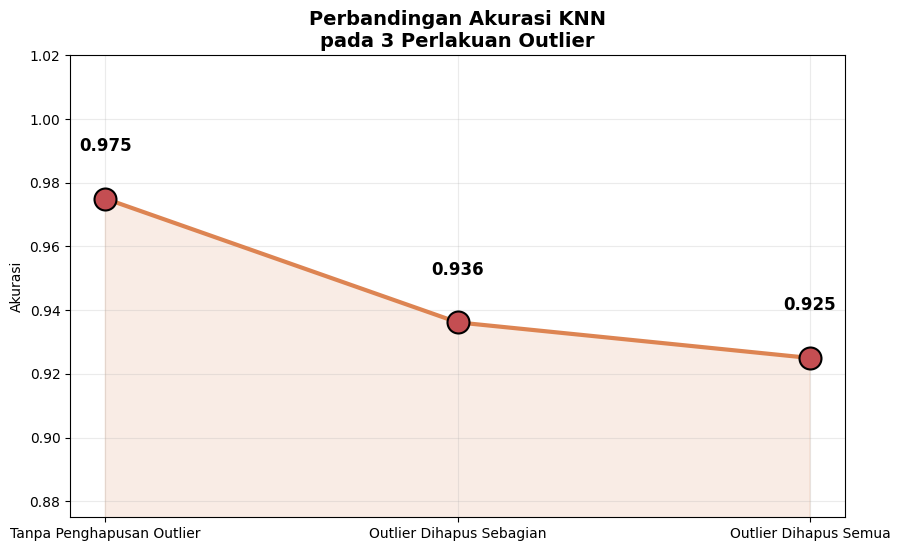

In [86]:
models = [
    "Tanpa Penghapusan Outlier",
    "Outlier Dihapus Sebagian",
    "Outlier Dihapus Semua"
]

acc_values = np.array([acc_knn_0, acc_knn_A, acc_knn_B])

plt.figure(figsize=(10, 6))

line_color = "#DD8452"
point_color = "#C44E52"

plt.plot(models, acc_values, color=line_color, linewidth=3)
plt.scatter(models, acc_values, color=point_color, s=250,
            edgecolors="black", linewidth=1.5, zorder=5)
plt.fill_between(models, acc_values, color=line_color, alpha=0.15)

for i, val in enumerate(acc_values):
    plt.text(i, val + 0.015, f"{val:.3f}", ha='center',
             fontsize=12, fontweight='bold')

plt.title(
    "Perbandingan Akurasi KNN\npada 3 Perlakuan Outlier",
    fontsize=14, fontweight='bold'
)
plt.ylabel("Akurasi")
plt.ylim(min(acc_values) - 0.05, 1.02)
plt.grid(alpha=0.25)
plt.show()
